In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve

### 1. Kütüphaneleri İçe Aktarma
Bu hücrede, veri analizi ve manipülasyonu için en temel Python kütüphanelerinden biri olan `pandas` içe aktarılıyor. Kodlamayı kolaylaştırmak için `pd` kısaltması kullanılıyor.

In [ ]:
# Dosya aynı klasördeyse:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

### 2. Veri Yükleme
Müşteri terk (churn) verilerini içeren CSV dosyası `read_csv` fonksiyonu kullanılarak okunuyor ve `df` adlı bir Pandas DataFrame (veri çerçevesi) nesnesine atanıyor.

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Veriye İlk Bakış
Veri setinin düzgün yüklenip yüklenmediğini ve içeriğinin neye benzediğini görmek için `head()` fonksiyonu ile ilk 5 satır görüntüleniyor.

In [ ]:
df.shape

(7043, 21)

### 4. Veri Boyutu
`shape` özelliği kullanılarak veri setinde toplam kaç gözlem (satır) ve kaç özellik (sütun) bulunduğu kontrol ediliyor.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 5. Veri Yapısı ve Tipleri
`info()` fonksiyonu, veri setindeki sütunların isimlerini, içerdikleri eksik olmayan değer sayısını ve veri tiplerini (sayısal, kategorik vs.) gösteren genel bir özet sunar.

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

### 6. Veri Tipi Dönüşümü
`TotalCharges` (Toplam Ücret) sütunu metin (object) formatında olduğu için sayısal bir formata (`float` veya `int`) dönüştürülüyor. `errors="coerce"` parametresi, dönüştürülemeyen hatalı veya boş değerlerin eksik değere (`NaN`) çevrilmesini sağlar.

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

### 7. Eksik Veri Kontrolü
Veri tipi dönüşümü sonrasında `TotalCharges` sütununda `NaN` (eksik değer) oluşan satırların toplam sayısı kontrol ediliyor.

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


### 8. Hedef Değişken Analizi
Modelin tahmin etmeye çalışacağı hedef değişken olan `Churn` (Müşteri Terki) sütununda yer alan 'Yes' (Terk eden) ve 'No' (Terk etmeyen) sınıflarının sayıca dağılımı inceleniyor.

In [ ]:
df.describe()
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


### 9. İstatistiksel Özet ve Oranlar
Sayısal değişkenlerin istatistiksel özeti çıkarılıyor ve hedef değişken olan `Churn` sınıflarının tüm veri seti içindeki yüzdelik oranları (normalize=True ile) görüntüleniyor.

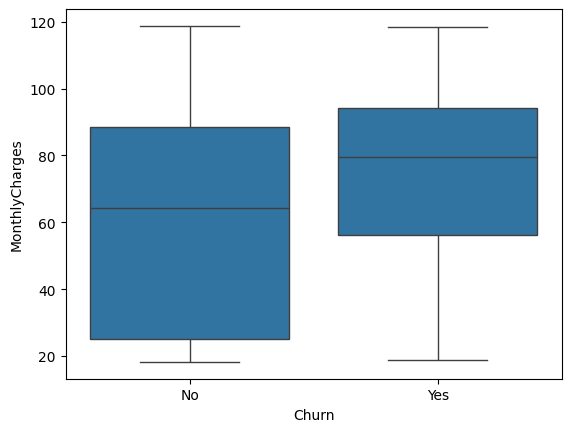

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

### 10. Görselleştirme: Kutu Grafiği (Aylık Ücret vs. Terk)
Müşterilerin aylık ücretlerinin (`MonthlyCharges`), müşteri terk etme durumuyla (`Churn`) olan ilişkisini ve olası aykırı değerleri incelemek için `seaborn` kütüphanesiyle bir kutu grafiği (boxplot) oluşturuluyor.

<Axes: xlabel='Contract', ylabel='count'>

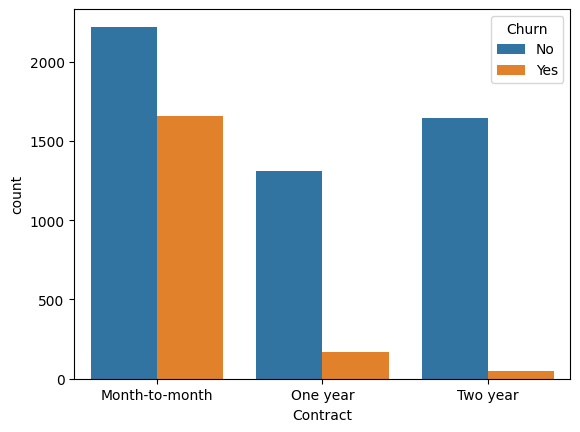

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)

### 11. Görselleştirme: Sayım Grafiği (Sözleşme Tipi vs. Terk)
Müşterilerin kontrat tiplerine (Aylık, 1 Yıllık, 2 Yıllık) göre dağılımı ve bu gruplar içindeki terk etme/etmeme (Churn) durumları görselleştiriliyor.

In [ ]:
df.drop("customerID", axis=1, inplace=True)

### 12. Gereksiz Sütunların Çıkarılması
`customerID` (Müşteri Numarası) modeli eğitirken herhangi bir anlam ifade etmeyen, her müşteriye özel eşsiz bir değer olduğu için veri setinden kalıcı olarak (`inplace=True`) çıkarılıyor.

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

### 13. Hedef Değişkeni Sayısallaştırma
Makine öğrenmesi algoritmaları metinleri doğrudan işleyemediği için `Churn` sütunundaki 'Yes' değerleri 1'e, 'No' değerleri ise 0'a dönüştürülerek sayısallaştırılıyor.

In [ ]:
df = df.dropna()

### 14. Eksik Verileri Temizleme
`dropna()` fonksiyonu kullanılarak, içerisinde `NaN` (eksik veri) barındıran tüm satırlar veri setinden siliniyor.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

### 15. Kategorik Değişkenleri Kodlama (One-Hot Encoding)
Sütunlardaki tüm kategorik metin değerleri algoritmaların anlayabileceği 1 ve 0'lardan oluşan ayrı sütunlara çevriliyor. `drop_first=True` parametresi kullanılarak *Dummy Variable Trap* (Kukla Değişken Tuzağı) denilen çoklu bağlantı probleminden kaçınılıyor.

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


### 16. İşlem Sonrası Hedef Değişken Dağılımı
Eksik veriler silinip hedef değişken sayısallaştırıldıktan sonra, Churn değişkeninin (0 ve 1'lerin) güncel sayısal dağılımı yeniden kontrol ediliyor.

In [ ]:
# müşteri başına aylık ortalama ödeme
df["AvgCharges"] = df["TotalCharges"] / df["tenure"]

### 17. Özellik Mühendisliği: Yeni Değişken Üretme (Ortalama Ücret)
Toplam ödenen ücretin (`TotalCharges`), müşterinin sistemde kaldığı ay sayısına (`tenure`) bölünmesiyle müşteri başına aylık tahmini ortalama harcamayı belirten yeni bir sütun (`AvgCharges`) oluşturuluyor.

In [ ]:
# yeni müşteri mi?
df["IsNew"] = (df["tenure"] < 12).astype(int)

### 18. Özellik Mühendisliği: Müşteri Durumu
Müşterinin firmada kalma süresi (`tenure`) 12 aydan kısaysa "yeni müşteri" varsayılarak değeri 1, aksi halde 0 olan `IsNew` adında yeni bir özellik veri setine ekleniyor.

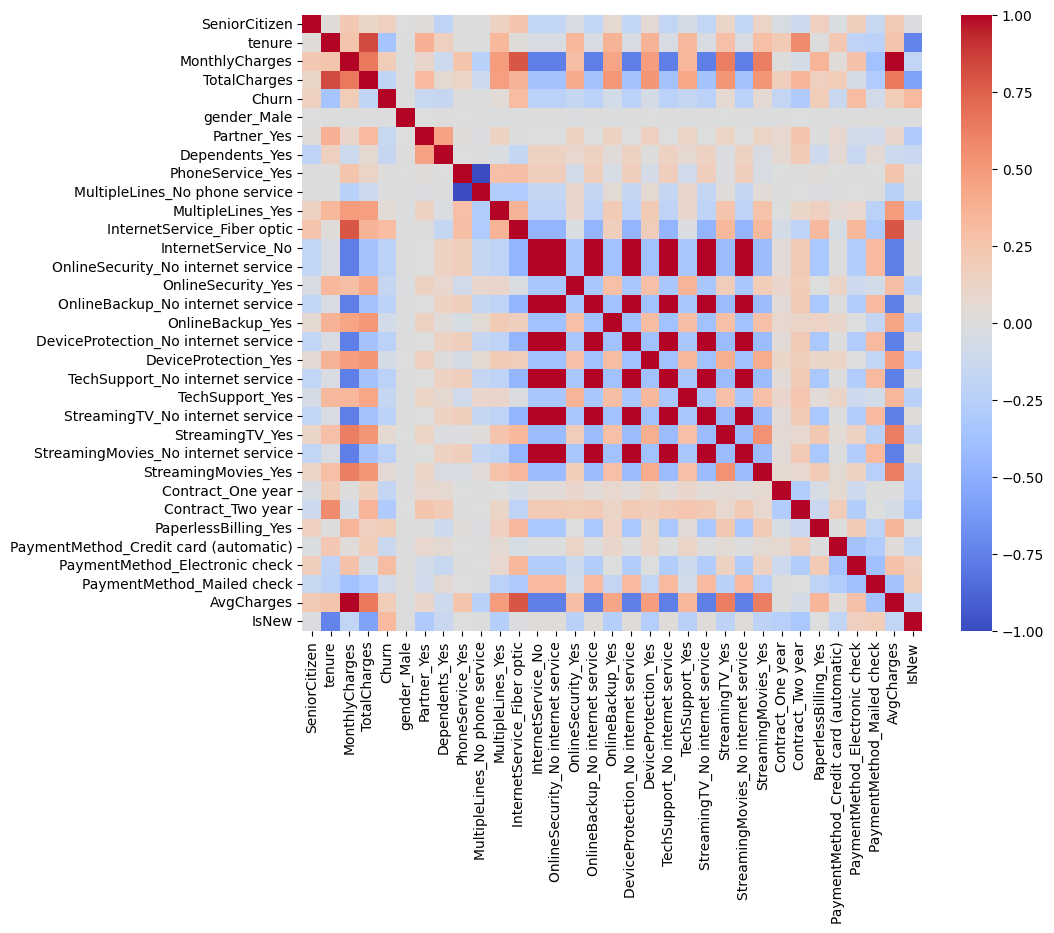

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

### 19. Korelasyon Analizi (Isı Haritası)
Değişkenlerin birbiriyle olan matematiksel ilişkisini (korelasyonunu) görmek için bir ısı haritası çizdiriliyor. Bu görsel, birbiriyle çok yüksek ilişkisi olan veya hedef değişkeni doğrudan etkileyen sütunları anlamaya yardımcı olur.

<Axes: xlabel='TotalCharges', ylabel='AvgCharges'>

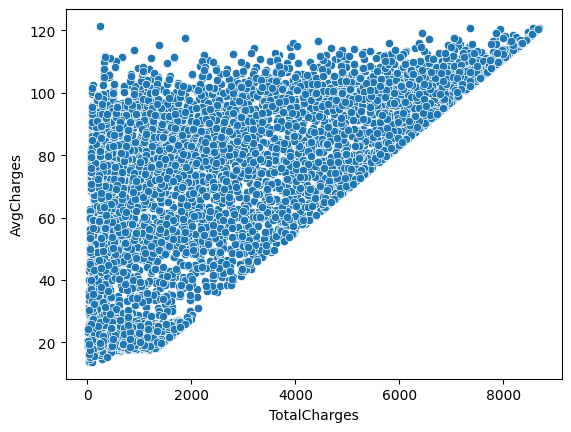

In [ ]:
sns.scatterplot(x=df["TotalCharges"], y=df["AvgCharges"])

### 20. Saçılım Grafiği (TotalCharges vs. AvgCharges)
Yeni oluşturulan ortalama harcama (`AvgCharges`) ile toplam harcama (`TotalCharges`) sütunları arasındaki doğrusal veya matematiksel ilişki, dağılım grafiğiyle görsel olarak inceleniyor.

In [ ]:
df.drop("TotalCharges", axis=1, inplace=True)

### 21. Yüksek Korelasyonlu Sütunu Kaldırma
`TotalCharges` sütunu, diğer değerlerden türetilmiş olması ve diğer sütunlarla yüksek korelasyon yaratıp modeli ezberlemeye itebileceği için çıkarılıyor.

“TotalCharges değişkeni, diğer değişkenlerle yüksek korelasyon göstermesi ve türetilmiş bir değişken olması nedeniyle modelden çıkarılmıştır.”

In [ ]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Churn', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'AvgCharges', 'IsNew'],
      dtype='object')

### 22. Son Sütunları Kontrol Etme
Yapılan dönüşümler, değişken üretimi ve sütun silme işlemleri sonrasında veri setinin sahip olduğu son model sütunlarının listesi kontrol ediliyor.

In [ ]:
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)

,Churn
Churn,1.000000
IsNew,0.319816
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
MonthlyCharges,0.192858
AvgCharges,0.192033
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860


<Figure size 1400x700 with 0 Axes>

In [ ]:
# Imports consolidated at the top

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407



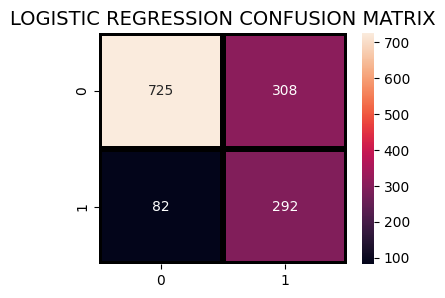

In [ ]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

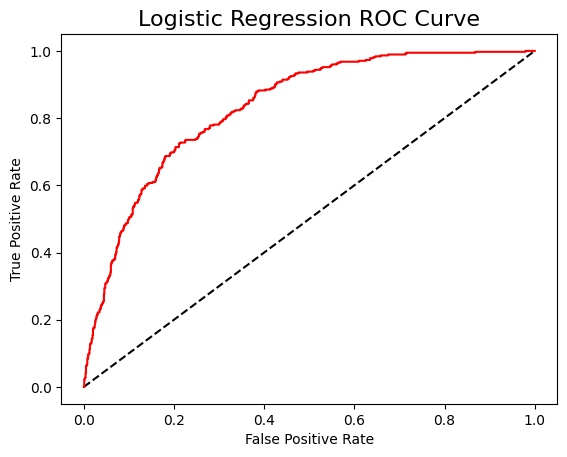

In [ ]:
y_pred_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve',fontsize=16)
plt.show();

### 24. Random Forest (Rastgele Orman) Modeli
Bu bölümde, birden fazla karar ağacının bir araya gelmesiyle oluşan güçlü bir topluluk (ensemble) öğrenme algoritması olan Random Forest modeli eğitilmektedir. Dengesiz veri setini yönetebilmek için `class_weight='balanced'` parametresi kullanılmıştır.

In [ ]:
# Imports consolidated at the top

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

In [ ]:
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=400, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.757640369580668
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407

Confusion Matrix:
 [[778 255]
 [ 86 288]]


**### - Model performansının artırılmasına yönelik çalışmalar --**

Random Forest modelinde azınlık sınıfını tahmin etme başarısını (Recall oranını) artırmak amacıyla bir dizi optimizasyon yapılmıştır:
* Veri setindeki dengesizliği gidermek için modele verilmeden önce **SMOTE** tekniği ile azınlık sınıfı çoğaltılmıştır.
* Modelin karar verme gücünü artırmak için ağaç sayısı (`n_estimators`) artırılmıştır.
* Aşırı öğrenmeyi (overfitting) kontrol altına almak adına `max_depth` (maksimum derinlik) ve `min_samples_leaf` değerleri yükseltilmiştir.
* Standart 0.50 olan karar eşiği (threshold) **0.30**'a düşürülerek, modelin 'Churn' (Terk) etme ihtimali olan müşterileri daha agresif bir şekilde yakalaması (yüksek Recall) sağlanmıştır.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.189184
24,Contract_Two year,0.114503
29,AvgCharges,0.085404
2,MonthlyCharges,0.080161
30,IsNew,0.075548
9,InternetService_Fiber optic,0.067462
27,PaymentMethod_Electronic check,0.053228
23,Contract_One year,0.046864
12,OnlineSecurity_Yes,0.031557
18,TechSupport_Yes,0.026291


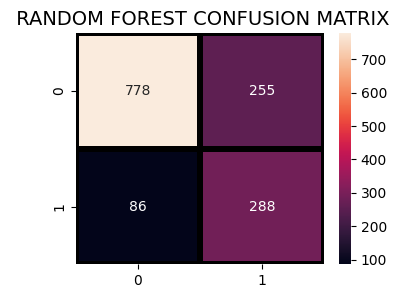

In [ ]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
                annot=True,fmt = "d",linecolor="k",linewidths=3)

plt.title(" RANDOM FOREST CONFUSION MATRIX",fontsize=14)
plt.show()

### 25. Destek Vektör Makineleri (SVM) Modeli
Bu bölümde, sınıfları (Churn: Evet/Hayır) birbirinden ayırmak için optimum hiperdüzlemi bulmayı amaçlayan Destek Vektör Makineleri (SVM) modeli oluşturulmaktadır. Radial Basis Function (`kernel='rbf'`) kullanılarak doğrusal olmayan ilişkiler de yakalanmaya çalışılmış ve yine sınıf dengesizliğine karşı ağırlıklandırma (`class_weight='balanced'`) yapılmıştır.

In [ ]:
# Imports consolidated at the top

In [ ]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    class_weight="balanced",
    probability=True,   # threshold için gerekli
    random_state=42
)

In [ ]:
svm_model.fit(X_train_scaled, y_train)

SVC(C=1, class_weight='balanced', probability=True, random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7228144989339019
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

Confusion Matrix:
 [[724 309]
 [ 81 293]]


In [ ]:
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.60
y_pred_svm_custom = (y_prob_svm > threshold).astype(int)

print("Custom Threshold Accuracy:", accuracy_score(y_test, y_pred_svm_custom))
print(classification_report(y_test, y_pred_svm_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_custom))

Custom Threshold Accuracy: 0.7626154939587776
              precision    recall  f1-score   support

           0       0.78      0.94      0.85      1033
           1       0.62      0.28      0.38       374

    accuracy                           0.76      1407
   macro avg       0.70      0.61      0.62      1407
weighted avg       0.74      0.76      0.73      1407

Confusion Matrix:
 [[969  64]
 [270 104]]


### 26. K-En Yakın Komşu (K-NN) Modeli
K-NN algoritması, bir veri noktasının sınıfını belirlerken ona en yakın olan 'k' adet komşusunun çoğunluk sınıfına bakar. Uzaklık ölçütü olarak standart 'minkowski' metriği kullanılmıştır.

In [ ]:
# Imports consolidated at the top

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski"
)

In [ ]:
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### K-NN Tahmin ve Değerlendirme
Eğitilen KNN modeli ile test verisi üzerinden tahminler (predict) üretilir ve modelin doğruluk oranı, Precision (Kesinlik), Recall (Duyarlılık) gibi metrikleri sınıflandırma raporu (classification report) ile değerlendirilir.

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.7547974413646056
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.54      0.55      0.54       374

    accuracy                           0.75      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.75      0.76      1407

Confusion Matrix:
 [[858 175]
 [170 204]]


In [ ]:
for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(f"k={k} -> Accuracy: {accuracy_score(y_test, y_pred):.4f}")

k=3 -> Accuracy: 0.7448
k=5 -> Accuracy: 0.7548
k=7 -> Accuracy: 0.7655
k=9 -> Accuracy: 0.7733
k=11 -> Accuracy: 0.7797
